# SVD & PCA from Scratch

This notebook covers:
1. **SVD via Eigendecomposition** — implementing SVD manually using `A^T A` and `A A^T`
2. **Image Compression** — low-rank approximation with numpy's built-in SVD
3. **PCA via SVD** — dimensionality reduction on the digits dataset and its effect on classifier accuracy

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from matplotlib.image import imread
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_digits
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

### Helper: Matrix Visualizer

In [2]:
def plot_matrix(matrix, title="Matrix", annotate=True):
    """Render a 2-D array as an annotated heatmap."""
    matrix_np = matrix if isinstance(matrix, np.ndarray) else matrix.numpy()

    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(matrix_np, annot=annotate, fmt=".2f",
                     linewidths=1, cbar=True, cmap="Blues")
    ax.set_title(title)
    ax.set_xticks(np.arange(matrix_np.shape[1]) + 0.5)
    ax.set_yticks(np.arange(matrix_np.shape[0]) + 0.5)
    ax.set_xticklabels([f"Col {i+1}" for i in range(matrix_np.shape[1])])
    ax.set_yticklabels([f"Row {i+1}" for i in range(matrix_np.shape[0])])
    plt.tight_layout()
    plt.show()

## 2. SVD via Eigendecomposition

**Key idea:** For any matrix `A`, the singular values and vectors can be recovered from the eigendecompositions of `A^T A` (gives V and σ) and `A A^T` (gives U).

Steps:
1. Compute `A^T A` → eigendecompose → right singular vectors **V**, singular values **σ = √λ**
2. Recover **U** column-by-column: `u_i = A v_i / σ_i`
3. Verify: `A ≈ U Σ V^T` and that U, V are orthogonal

In [3]:
def compute_svd_via_eigen(A):
    """
    Compute SVD via eigendecomposition of A^T A and A A^T.

    Returns
    -------
    U  : (m, m) left singular vectors
    S  : (m, n) diagonal matrix of singular values
    V  : (n, n) right singular vectors
    """
    m, n = A.shape

    ATA = A.T @ A   # (n × n)
    AAT = A @ A.T   # (m × m)

    # Eigendecompose both — eigh is stable for symmetric matrices
    eigvals_ATA, eigvecs_ATA = np.linalg.eigh(ATA)
    eigvals_AAT, eigvecs_AAT = np.linalg.eigh(AAT)

    # Sort descending (eigh returns ascending)
    eigvecs_ATA = eigvecs_ATA[:, np.argsort(eigvals_ATA)[::-1]]
    eigvals_ATA = np.sort(eigvals_ATA)[::-1]
    eigvecs_AAT = eigvecs_AAT[:, np.argsort(eigvals_AAT)[::-1]]

    # Singular values
    S_vals = np.sqrt(np.maximum(eigvals_ATA, 0))

    V = eigvecs_ATA
    U = eigvecs_AAT.copy()

    # Recompute U columns from A to guarantee sign consistency with V
    for i in range(min(m, n)):
        if S_vals[i] > 1e-10:
            U[:, i] = (A @ V[:, i]) / S_vals[i]

    # Build full Σ matrix
    S_full = np.zeros((m, n))
    np.fill_diagonal(S_full, S_vals[:min(m, n)])

    return U, S_full, V

### Smoke test on a simple matrix

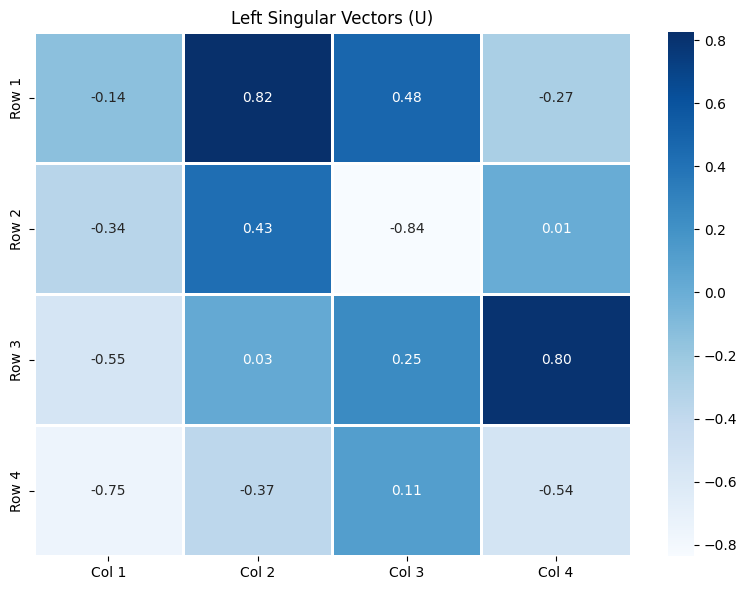

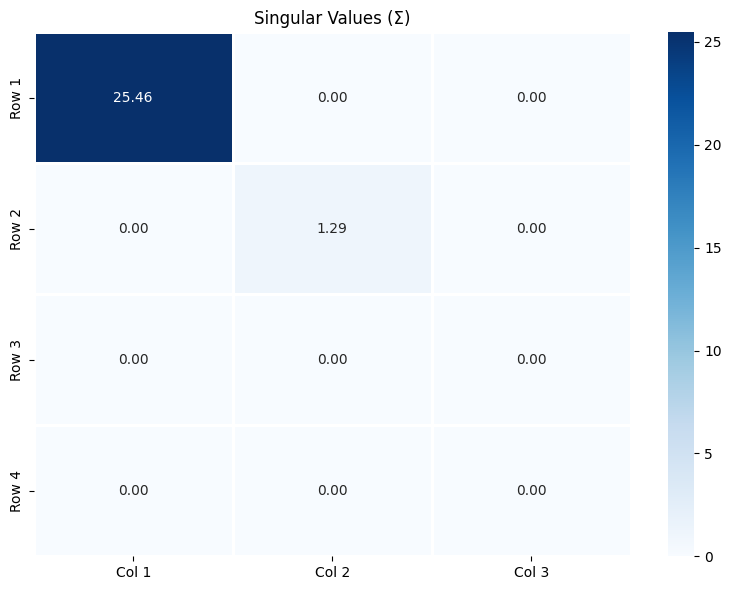

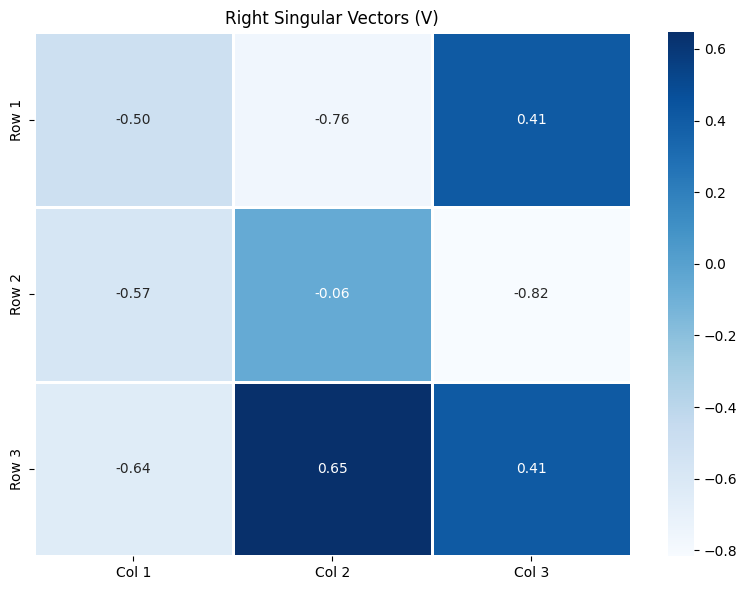

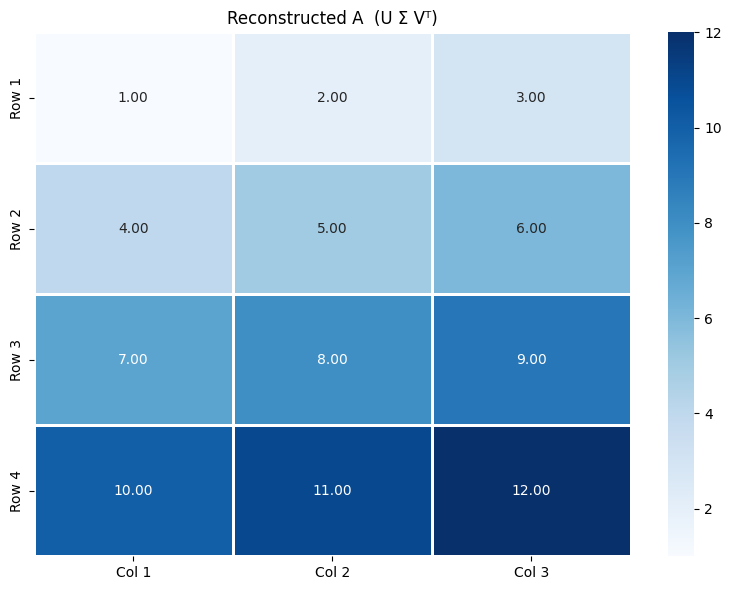

Reconstruction error: 3.43e-14


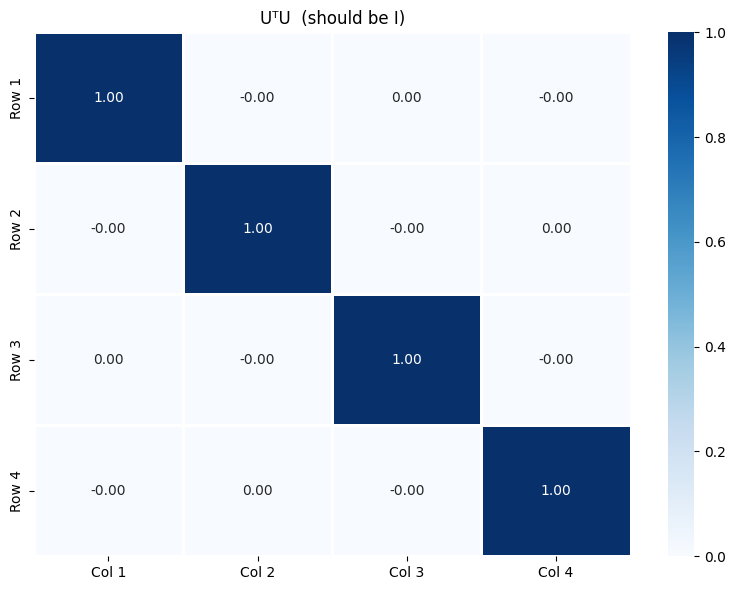

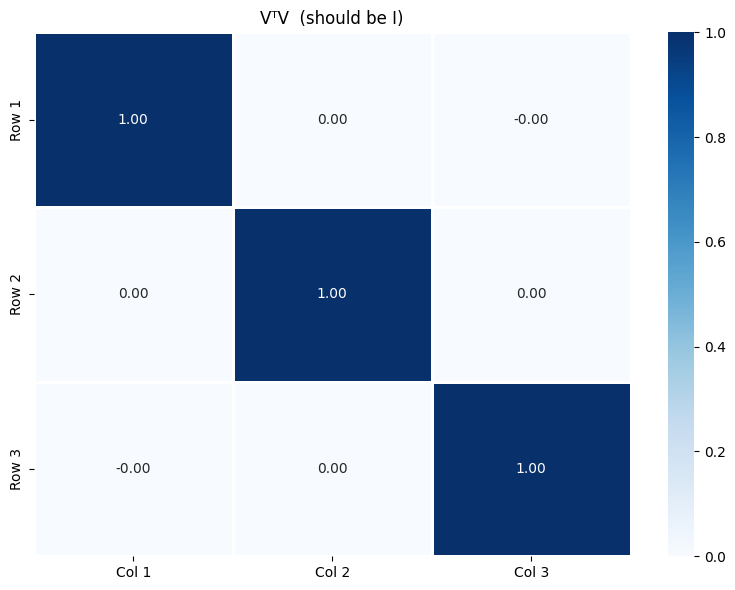

In [4]:
A_simple = np.array([
    [1,  2,  3],
    [4,  5,  6],
    [7,  8,  9],
    [10, 11, 12]
], dtype=float)

U, S, V = compute_svd_via_eigen(A_simple)

plot_matrix(U, "Left Singular Vectors (U)")
plot_matrix(S, "Singular Values (Σ)")
plot_matrix(V, "Right Singular Vectors (V)")

# Reconstruction check
A_reconstructed = U @ S @ V.T
plot_matrix(A_reconstructed, "Reconstructed A  (U Σ Vᵀ)")
print(f"Reconstruction error: {np.linalg.norm(A_simple - A_reconstructed):.2e}")

# Orthogonality check — both should be ≈ identity
plot_matrix(U.T @ U, "UᵀU  (should be I)")
plot_matrix(V.T @ V, "VᵀV  (should be I)")

## 3. Image Compression via Low-Rank Approximation

SVD lets us approximate a matrix `A` using only the top `r` singular values/vectors:

    A_approx = U[:, :r] @ Σ[:r, :r] @ Vᵀ[:r, :]

The first singular values capture the most "energy" (variance) in the image,
so even a small `r` gives a recognizable result. We use numpy's built-in SVD here
because it's numerically optimized — the custom eigen-based one above is for understanding the math.

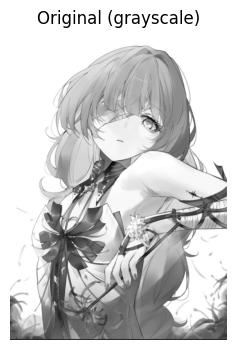

In [5]:
# Load image and convert to grayscale
A = imread("test.png")
X = np.mean(A, axis=-1)   # RGB → grayscale by averaging channels

plt.figure(figsize=(6, 4))
img = plt.imshow(X, cmap="gray")
plt.axis("off")
plt.title("Original (grayscale)")
plt.show()

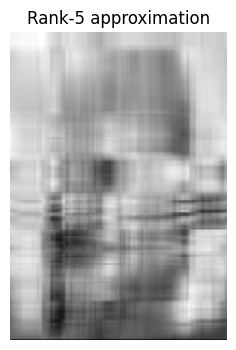

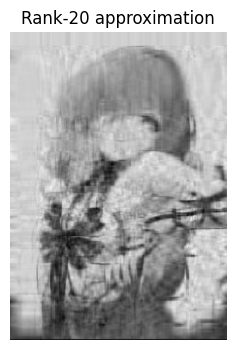

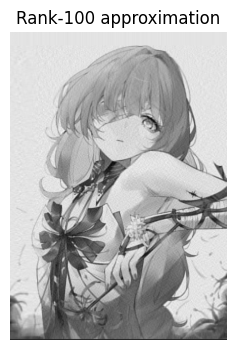

In [6]:
# Economy SVD (full_matrices=False): only keep columns/rows tied to non-zero singular values
u, s, vt = np.linalg.svd(X, full_matrices=False)
S_diag = np.diag(s)

# Low-rank reconstructions at increasing rank r
for r in [5, 20, 100]:
    X_approx = u[:, :r] @ S_diag[:r, :r] @ vt[:r, :]
    plt.figure(figsize=(6, 4))
    plt.imshow(X_approx, cmap="gray")
    plt.axis("off")
    plt.title(f"Rank-{r} approximation")
    plt.show()

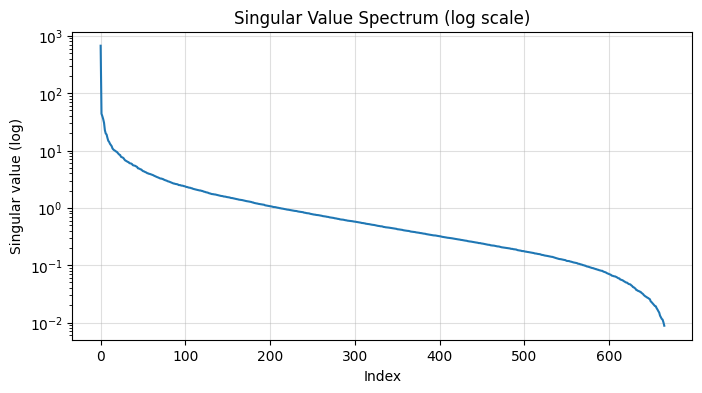

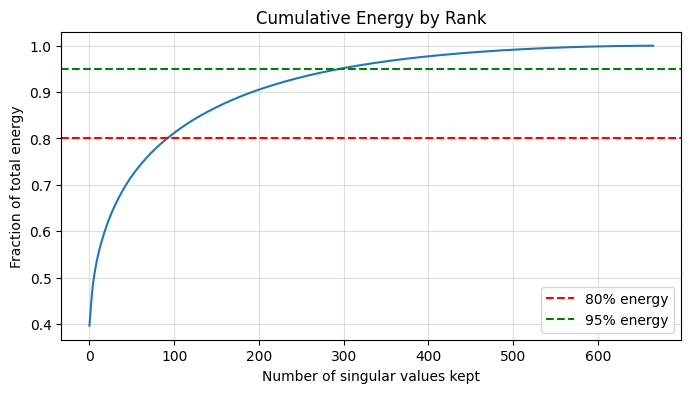

In [7]:
# Singular value spectrum — log scale shows the rapid energy drop-off
plt.figure(figsize=(8, 4))
plt.semilogy(np.diag(S_diag))
plt.title("Singular Value Spectrum (log scale)")
plt.xlabel("Index")
plt.ylabel("Singular value (log)")
plt.grid(True, alpha=0.4)
plt.show()

# Cumulative energy — tells us how many components we need to capture X% of the image
plt.figure(figsize=(8, 4))
cumulative = np.cumsum(np.diag(S_diag) / np.sum(np.diag(S_diag)))
plt.plot(cumulative)
plt.axhline(0.8, color="r", linestyle="--", label="80% energy")
plt.axhline(0.95, color="g", linestyle="--", label="95% energy")
plt.title("Cumulative Energy by Rank")
plt.xlabel("Number of singular values kept")
plt.ylabel("Fraction of total energy")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

## 4. Principal Component Analysis (PCA) via SVD

PCA finds the directions of maximum variance in the data.
It's literally SVD applied to the **mean-centered** data matrix:

- Center the data: `X_c = X - mean(X)`
- Run SVD: `X_c = U Σ Vᵀ`
- The rows of `Vᵀ` are the **principal components** (directions)
- Project: `X_transformed = X_c @ V[:k]ᵀ` gives the low-dim representation
- **Variance explained** by each component ∝ σᵢ²

In [8]:
def pca_with_svd(X, n_components=2):
    """
    PCA via SVD on centered data.

    Parameters
    ----------
    X            : (n_samples, n_features) array
    n_components : number of principal components to keep

    Returns
    -------
    X_transformed     : (n_samples, n_components) projected data
    components        : (n_components, n_features) principal component directions
    explained_variance: fraction of variance explained by each kept component
    """
    X_centered = X - np.mean(X, axis=0)
    _, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

    components = Vt[:n_components]
    X_transformed = X_centered @ components.T

    explained_variance = (S**2)[:n_components] / np.sum(S**2)
    return X_transformed, components, explained_variance

### Dataset: Sklearn Digits (8×8 pixel handwritten digits, 10 classes)

In [9]:
dataset = load_digits()
print("Data shape :", dataset.data.shape)   # (1797, 64)
print("Classes    :", np.unique(dataset.target))

Data shape : (1797, 64)
Classes    : [0 1 2 3 4 5 6 7 8 9]


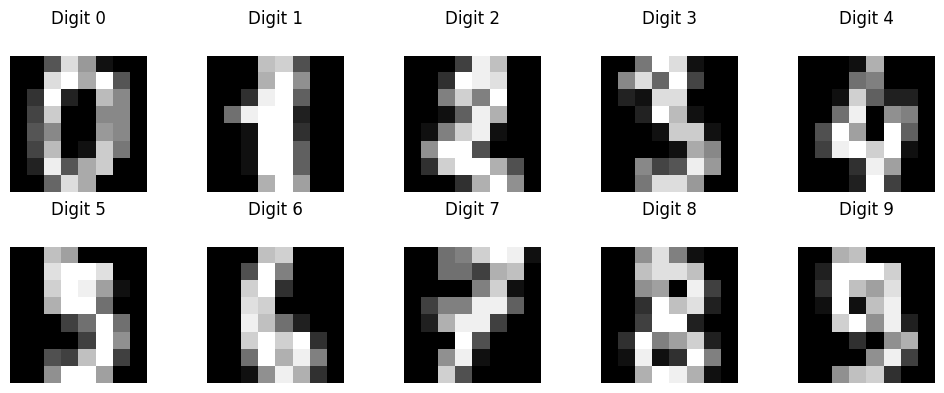

In [10]:
# Visual sanity check — one example of each digit
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit in range(10):
    idx = np.where(dataset.target == digit)[0][0]
    ax = axes[digit // 5][digit % 5]
    ax.matshow(dataset.data[idx].reshape(8, 8), cmap="gray")
    ax.set_title(f"Digit {digit}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [11]:
X = pd.DataFrame(dataset.data, columns=dataset.feature_names)
y = dataset.target

### Baseline: Logistic Regression on raw 64-dimensional features

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)
model = LogisticRegression()
model.fit(X_train, y_train)
baseline_acc = model.score(X_test, y_test)
print(f"Baseline accuracy (64 features): {baseline_acc:.2%}")

Baseline accuracy (64 features): 96.67%


### PCA with 2 components — how much variance is retained?

In [13]:
X_transformed, components, explained_variance = pca_with_svd(X, n_components=2)
print(f"Shape after PCA: {X_transformed.shape}")
print(f"Variance explained by 2 components: {explained_variance.sum():.2%}")

X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=30)
model_pca = LogisticRegression()
model_pca.fit(X_train_pca, y_train)
print(f"Accuracy with 2 PCA components: {model_pca.score(X_test_pca, y_test):.2%}")

Shape after PCA: (1797, 2)
Variance explained by 2 components: 28.51%
Accuracy with 2 PCA components: 60.28%


### Finding the minimum components needed for 95% variance

In [14]:
results = []

for k in range(1, 65):
    X_t, _, exp_var = pca_with_svd(X, k)
    X_tr, X_te, y_tr, y_te = train_test_split(X_t, y, test_size=0.2, random_state=30)
    model = LogisticRegression()
    model.fit(X_tr, y_tr)
    acc = model.score(X_te, y_te)
    results.append({"k": k, "variance_explained": exp_var.sum(), "accuracy": acc})
    if exp_var.sum() >= 0.95:
        print(f"95% variance reached at k={k}  |  Accuracy: {acc:.2%}")
        break

results_df = pd.DataFrame(results)
print(results_df.tail())

95% variance reached at k=29  |  Accuracy: 97.22%
     k  variance_explained  accuracy
24  25            0.933033  0.963889
25  26            0.938993  0.966667
26  27            0.944750  0.958333
27  28            0.949901  0.966667
28  29            0.954797  0.972222


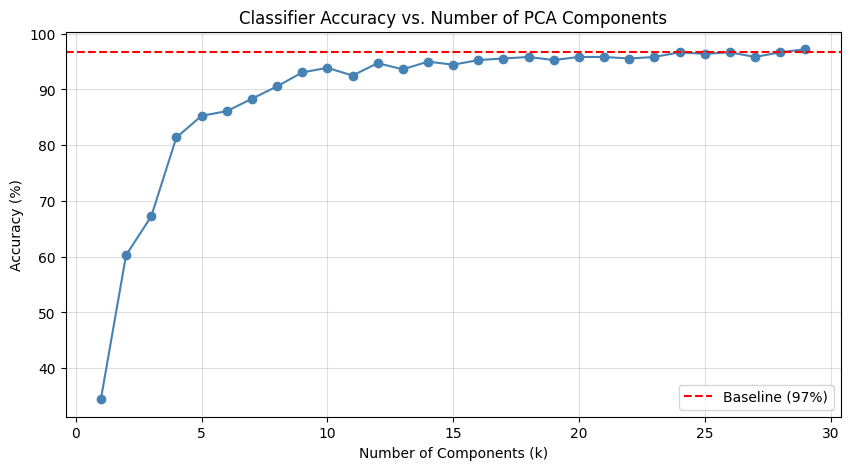

In [15]:
# Accuracy vs number of PCA components
plt.figure(figsize=(10, 5))
plt.plot(results_df["k"], results_df["accuracy"] * 100, marker="o", color="steelblue")
plt.axhline(baseline_acc * 100, color="red", linestyle="--", label=f"Baseline ({baseline_acc:.0%})")
plt.title("Classifier Accuracy vs. Number of PCA Components")
plt.xlabel("Number of Components (k)")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

### What are the principal components made of?

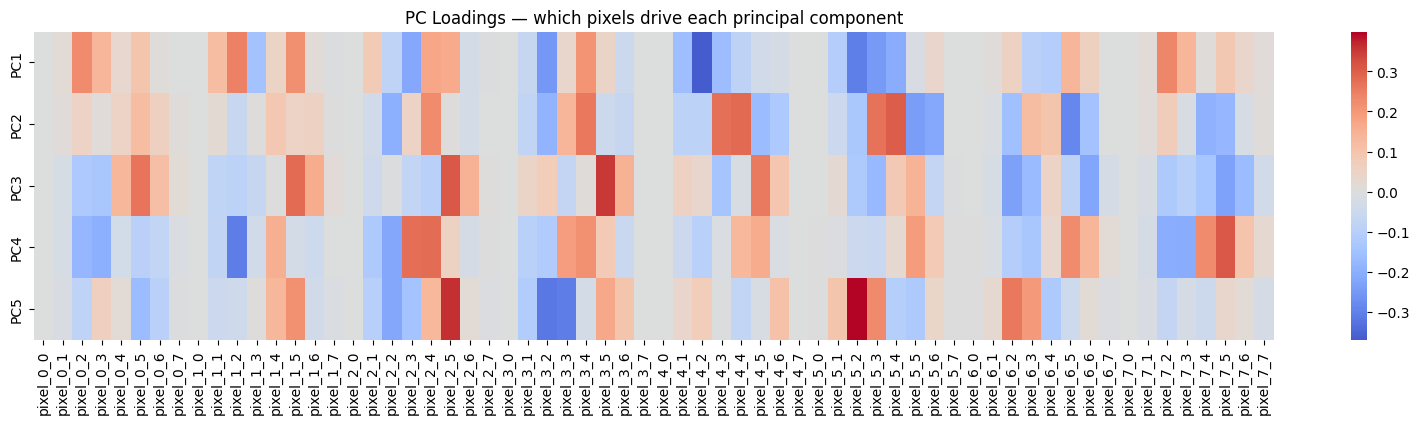

In [16]:
k = 5
X_t, comps, _ = pca_with_svd(X, k)

loadings_df = pd.DataFrame(
    comps,
    columns=X.columns,
    index=[f"PC{i+1}" for i in range(k)]
)

plt.figure(figsize=(20, 4))
sns.heatmap(loadings_df, cmap="coolwarm", center=0)
plt.title("PC Loadings — which pixels drive each principal component")
plt.show()